# Noise Model Detection
Paper-ready AR(2) detection figure using the shared detector/noise framework, including the analytic baselines, the oracle mode, and the AR(2) flow model.

In [1]:
from pathlib import Path
import sys
import yaml
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import Config
from src.model.flow_matching_model.samples import Samples
from src.utils.cyclic_detector import CyclicDetector
from src.utils.drw import DRWManager
from src.utils.light_curve_sin_dataset import LightCurvesSinDataset
from src.utils.noise_models import AR1NoiseModel, AR2NoiseModel
from src.utils.rendering import plot_pvalue_histograms_from_items, plot_rocs_from_items
import src.model.flow_matching_model as flow_matching

NOTEBOOK_DIR = ROOT / 'figures' / 'noise_model_detection_new'
ROC_PATH = NOTEBOOK_DIR / 'noise_model_detection_roc.png'
PVALUE_PATH = NOTEBOOK_DIR / 'noise_model_detection_p_values.png'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 7

torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
def load_config(output_name: str) -> Config:
    with open(ROOT / 'outputs' / output_name / 'config.yaml', 'r') as handle:
        return Config(**yaml.safe_load(handle))


def load_flow_model(output_name: str, checkpoint_name: str):
    config = load_config(output_name)
    wrapper_cls = getattr(flow_matching, config.lightning_wrapper)
    checkpoint_path = ROOT / 'outputs' / output_name / checkpoint_name
    model = wrapper_cls.load_from_checkpoint(checkpoint_path, config=config, map_location=DEVICE)
    return model.eval().to(DEVICE)


class PaperFlowNoiseModel:
    def __init__(self, model, num_steps: int = 40):
        self.model = model
        self.num_steps = int(num_steps)

    @torch.no_grad()
    def generates_curves_like(self, reference_curves, parameters, num_curves):
        curves = torch.as_tensor(reference_curves, dtype=torch.float32, device=self.model.device)
        if curves.ndim == 2:
            curves = curves[:, None, :]
        domain_curves = self.model.to_domain(Samples(curves, domain='time', t=1)).curves
        condition = self.model.encode(domain_curves)
        condition = condition[:, None].repeat(1, num_curves, 1).flatten(0, 1)
        generated = self.model.domain_sample(condition.shape[0], condition=condition, num_steps=self.num_steps)
        time_curves = self.model.to_domain(generated, 'time').curves[:, 0]
        return time_curves.reshape(curves.shape[0], num_curves, -1).cpu()

    @torch.no_grad()
    def generate_curves(self, num_curves):
        generated = self.model.domain_sample(int(num_curves), num_steps=self.num_steps)
        curves = self.model.to_domain(generated, 'time').curves[:, 0].cpu()
        return curves, None


In [3]:
SIGMA = 0.1
DATASET_SIZE = 400
NUM_MC_CURVES = 100
BATCH_SIZE = 20
CYCLE_RANGE = (30, 80)
SNR_RANGE = (0.8, 1.2)

seed_all(SEED)
manager = DRWManager(sigma=SIGMA, observation_noise=0.0)
generating_noise_model = AR2NoiseModel(manager)

dataset = LightCurvesSinDataset(
    generating_noise_model,
    cycle_length_range=CYCLE_RANGE,
    snr_rms_range=SNR_RANGE,
    dataset_size=DATASET_SIZE,
    seed=SEED,
)

flow_model = load_flow_model('gaussian prior - drw ar2', 'step=step=025000.ckpt')

models = {
    'AR(1) - Misfit': AR1NoiseModel(manager),
    'AR(2) - Estimated': AR2NoiseModel(manager),
    'AR(2) - Oracle': AR2NoiseModel(manager, oracle_mode=True),
    'Generative model': PaperFlowNoiseModel(flow_model, num_steps=40),
}

results = {}
for index, (name, noise_model) in enumerate(models.items()):
    seed_all(SEED * 100 + index)
    detector = CyclicDetector(dataset, noise_model, num_simulated_light_curves=NUM_MC_CURVES)
    p_values, labels = detector.get_p_value_for_dataset(batch_size=BATCH_SIZE)
    results[name] = {'p_values': p_values.cpu(), 'labels': labels.cpu()}

summary = {
    name: round(float((1.0 - values['p_values'][values['labels']]).mean()), 4)
    for name, values in results.items()
}
summary


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(
100%|██████████| 20/20 [01:15<00:00,  3.79s/it]


{'AR(1) - Misfit': 0.9772,
 'AR(2) - Estimated': 0.9012,
 'AR(2) - Oracle': 0.9765,
 'Generative model': 0.9285}

PosixPath('/nfs/scistore20/bronsgrp/nsellam/astro-diffusion/figures/noise_model_detection_new/noise_model_detection_roc.png')

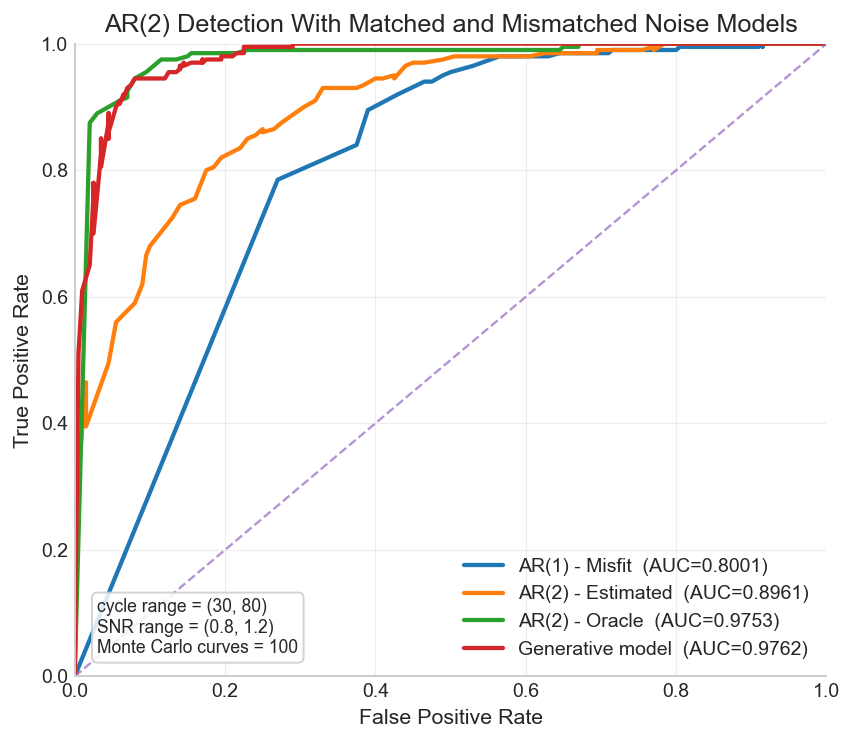

In [4]:
roc_items = [
    (name, payload['p_values'], payload['labels'])
    for name, payload in results.items()
]

fig, ax = plt.subplots(figsize=(6.2, 5.4))
plot_rocs_from_items(
    roc_items,
    ax=ax,
    title='AR(2) Detection With Matched and Mismatched Noise Models',
)
ax.text(
    0.03,
    0.03,
    f'cycle range = {CYCLE_RANGE}\nSNR range = {SNR_RANGE}\nMonte Carlo curves = {NUM_MC_CURVES}',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9,
    bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '0.8'},
)
fig.tight_layout()
fig.savefig(ROC_PATH, bbox_inches='tight')
ROC_PATH


PosixPath('/nfs/scistore20/bronsgrp/nsellam/astro-diffusion/figures/noise_model_detection_new/noise_model_detection_p_values.png')

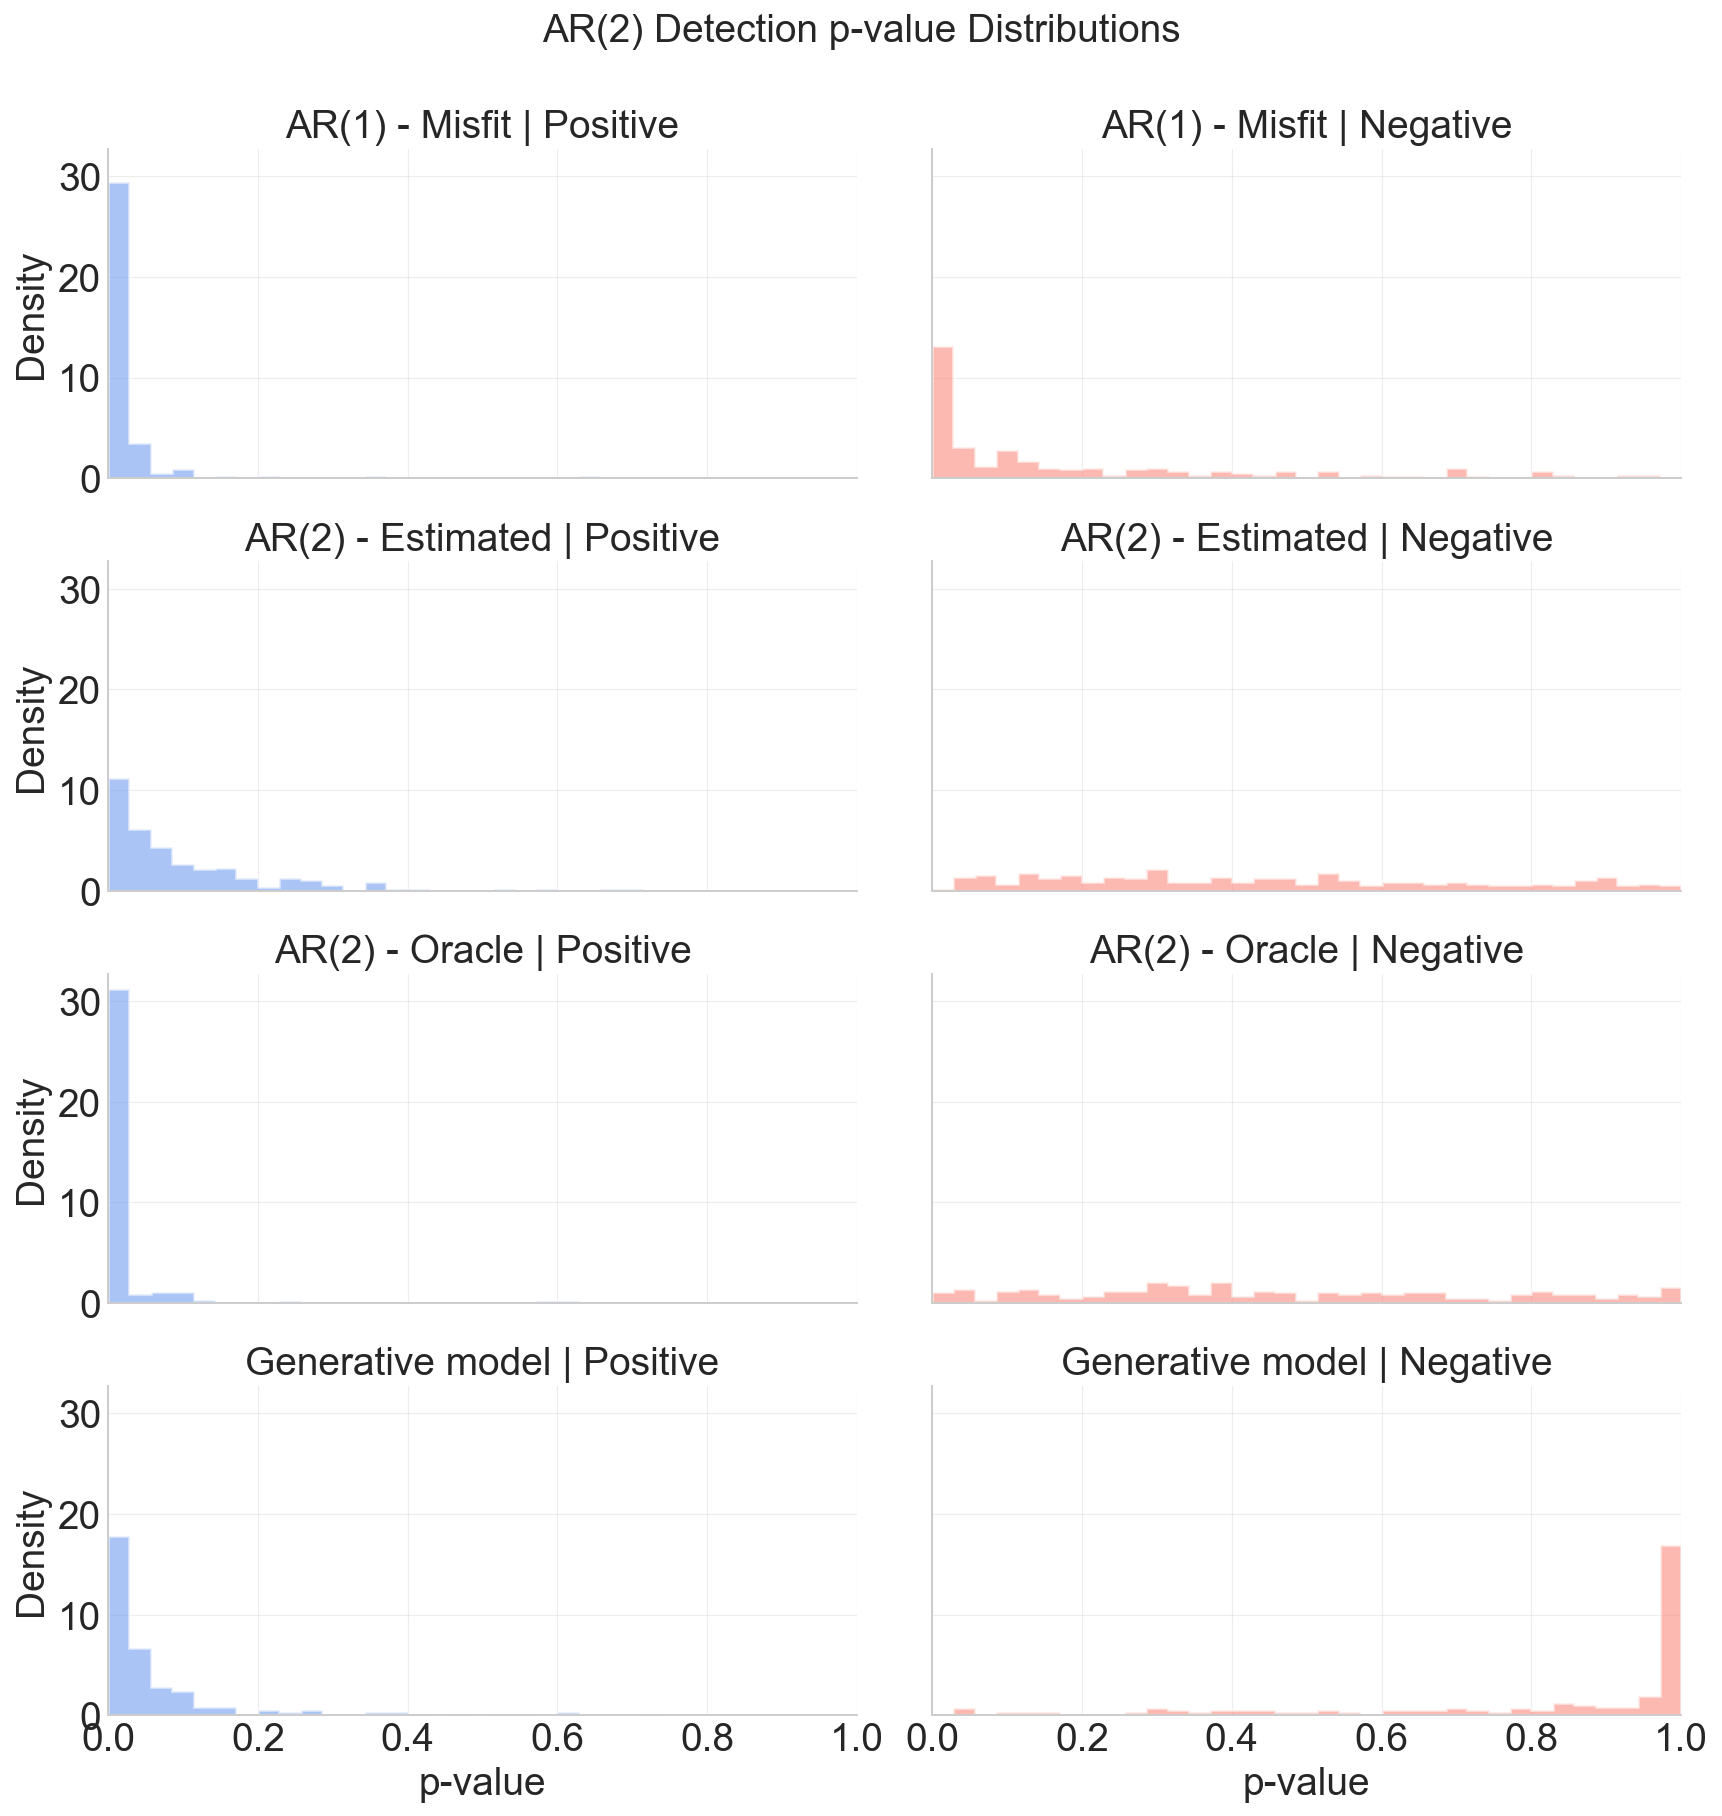

In [5]:
hist_items = [
    (name, payload['p_values'], payload['labels'])
    for name, payload in results.items()
]

fig, _ = plot_pvalue_histograms_from_items(
    hist_items,
    bins=35,
    title='AR(2) Detection p-value Distributions',
    fontsize=20
)
fig.savefig(PVALUE_PATH, bbox_inches='tight')
PVALUE_PATH


In [6]:
for name, payload in results.items():
    positives = payload['p_values'][payload['labels']]
    negatives = payload['p_values'][~payload['labels']]
    print(
        f"{name:>12} | positive mean p = {positives.mean():.4f} | negative mean p = {negatives.mean():.4f}"
    )


AR(1) - Misfit | positive mean p = 0.0228 | negative mean p = 0.1876
AR(2) - Estimated | positive mean p = 0.0988 | negative mean p = 0.4451
AR(2) - Oracle | positive mean p = 0.0235 | negative mean p = 0.4720
Generative model | positive mean p = 0.0715 | negative mean p = 0.7983
